In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
#intertia_

In [2]:
ss = StandardScaler()
le = LabelEncoder()
cols = ["sl","sw","pl","pw","class"]
df = pd.read_csv("Downloads/iris.data",header=None,names=cols)
df["class"] = le.fit_transform(df["class"])
# X = df.drop(df["class"],axis=0)
# X
y = df["class"]
y = np.array(y)
X = df.drop(columns=["class"])
X =  np.array(X)
pca = PCA()
pca.fit(X,y)
vr = pca.explained_variance_ratio_
sum = np.cumsum(vr)
idx = np.argmax(sum >= 0.95) + 1
k=1
for i in vr:
    print("VARAINCE RATIO FOR FEATURE-",k,"is --",i*100)
    k=k+1
print("\n")
print("TOTAL NUMBER OF FEATURE NEEDED TO CROSS THE 95% WAS ",idx)
km = KMeans(n_clusters=3,random_state=42)
labels = km.fit_predict(X,y)
wcss = km.inertia_
print("within cluster variation BEFORE pca applied was ",wcss)
X_temp = X.copy()
# mean-0.,var=1:: standarisation..
X = ss.fit_transform(X)

VARAINCE RATIO FOR FEATURE- 1 is -- 92.4616207174267
VARAINCE RATIO FOR FEATURE- 2 is -- 5.301556785053429
VARAINCE RATIO FOR FEATURE- 3 is -- 1.7185139525008415
VARAINCE RATIO FOR FEATURE- 4 is -- 0.5183085450190227


TOTAL NUMBER OF FEATURE NEEDED TO CROSS THE 95% WAS  2
within cluster variation BEFORE pca applied was  78.9450658259773


In [3]:
# pca = PCA()
# pca.fit(X,y)
# vr = pca.explained_variance_ratio_
# sum = np.cumsum(vr)
# idx = np.argmax(sum >= 0.95) + 1
# k=1
# for i in vr:
#     print("VARAINCE RATIO FOR FEATURE-",k,"is --",i*100)
#     k=k+1
# print("\n")
# print("TOTAL NUMBER OF FEATURE NEEDED TO CROSS THE 95% WAS ",idx)

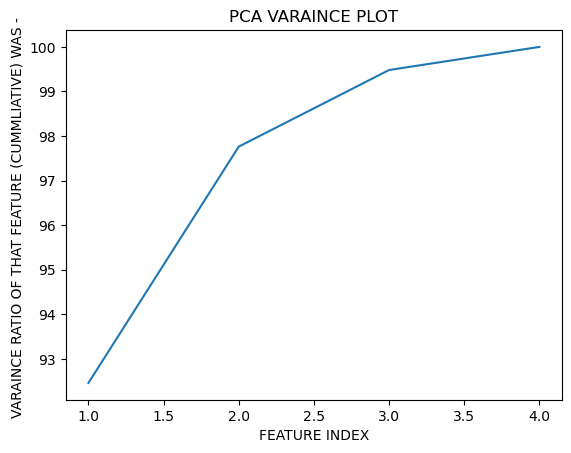

In [4]:
plt.plot(range(1,5),sum*100)
plt.xlabel("FEATURE INDEX")
plt.ylabel("VARAINCE RATIO OF THAT FEATURE (CUMMLIATIVE) WAS - ")
plt.title("PCA VARAINCE PLOT")
plt.show()


In [9]:
pca = PCA(n_components=2)
x_km = pca.fit_transform(X,y)
# km_new = Kmeans.p
# labels1 = km.fit(x_km,y)
# wcss = km.inertia_
km1 = KMeans(n_clusters=3)
labels1 = km1.fit_predict(x_km,y)
wcss1 = km1.inertia_
# print("within cluster variation BEFORE pca applied was ",wcss)
print("within cluster variation AFTER PCA applied was ",wcss1)

within cluster variation AFTER PCA applied was  116.24247259315807


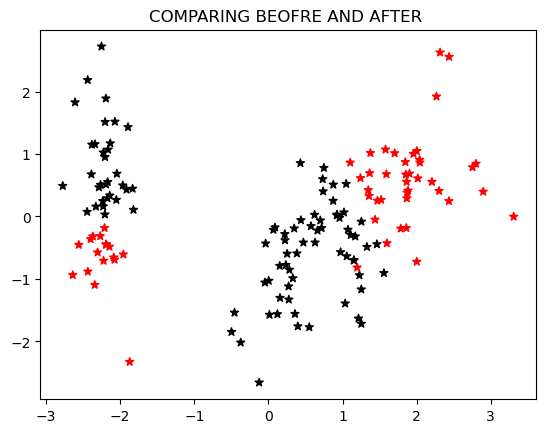

In [6]:
# red -0,green -1,blue-2..,3 for ddiferent..
labels_new = []
for i in range(len(labels)):
    if labels[i] == labels1[i] :
        labels_new.append(labels[i])
    else :
        labels_new.append(3)
        
colours=[]
for i in range(len(labels)):
    if labels_new[i] == 3:
        colours.append("black")
    else :
        colours.append("red")
# plt.scatter(range(1,len1+1), labels_new,c= colours,marker="*",linestyle="")
plt.scatter(x_km[:,0],x_km[:,1],c= colours,marker="*",linestyle="")
plt.title("COMPARING BEOFRE AND AFTER ")
plt.show()

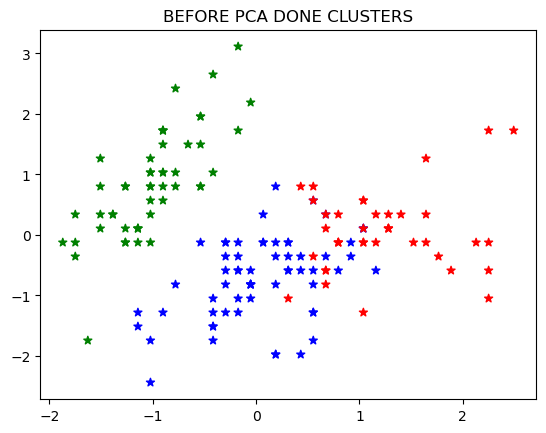

In [7]:
color = []
for i in range(len(labels)):
    if labels[i] == 0 :
        color.append("red")
    elif labels[i] == 1 :
        color.append("green")
    else:
        color.append("blue")
plt.scatter(X[:,0],X[:,1],c=color,marker="*",linestyle="")
plt.title("BEFORE PCA DONE CLUSTERS")
plt.show()

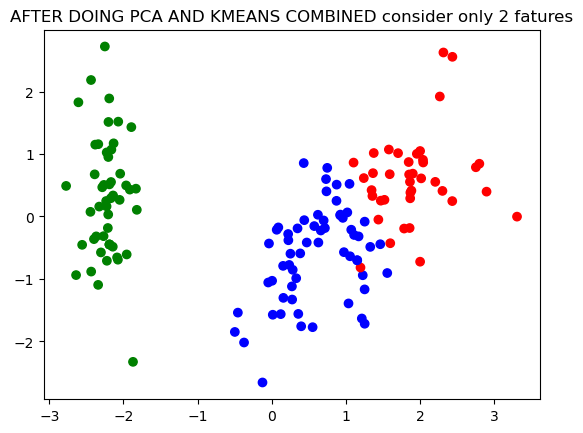

In [8]:
color1=[]
for i in range(len(labels1)):
    if labels[i] == 0 :
        color1.append("red")
    elif labels[i] == 1 :
        color1.append("green")
    else:
        color1.append("blue")
plt.scatter(x_km[:,0],x_km[:,1],c=color1,marker="o",linestyle="")
plt.title("AFTER DOING PCA AND KMEANS COMBINED consider only 2 fatures")
plt.show()